In [1]:
!nvidia-smi

Wed May 27 10:03:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           On  |   00000000:B2:00.0 Off |                    0 |
| N/A   24C    P0             40W /  300W |       1MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/ocean/projects/asc170022p/mtragoza/lung-project/notebooks/copdgene'

In [3]:
import sys, os
sys.path.append(os.environ['LP'])
import project
from project.core.utils import pprint

In [4]:
data_root = '/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene'
#data_root = '/restricted/projectnb/batmanlab/mragoza/COPDGene'

In [5]:
import project.datasets.copdgene
dataset_cls = project.datasets.copdgene.COPDGeneDataset
ds = dataset_cls(data_root)
ds

project.datasets.copdgene.COPDGeneDataset('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene')

# Visualize source images

In [6]:
examples = ds.list_examples(
    subjects='../../data/COPDGene/sample1000_2025-05-21.csv',
    state_pairs=[('EXP', 'INSP')]
)
len(examples)

1000

In [7]:
ex = examples[0]
pprint(ex, 4, 20)

Example()
├── dataset:  'COPDGene'
├── subject:  '16514P'
├── variant:  None
├── paths:    dict(len=3)
|   ├── 'ref_state':  dict(len=2)
|   |   ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz')
|   |   └── 'source_json':  PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.json')
|   ├── 'init_state': dict(len=2)
|   |   ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz')
|   |   └── 'source_json':  PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.json')
|   └── 'curr_state': dict(len=2)
|       ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.

In [8]:
import numpy as np
import nibabel as nib

img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['source_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['source_image'])

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
print(spacing0)

spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))
print(spacing1)

img0.affine

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz
(-0.71875, 0.71875, 0.5)
(-0.71875, 0.71875, 0.7000007629394531)


array([[  -0.71875 ,   -0.      ,    0.      ,  167.640625],
       [   0.      ,    0.71875 ,    0.      ,   -6.640625],
       [   0.      ,    0.      ,    0.5     , -319.      ],
       [   0.      ,    0.      ,    0.      ,    1.      ]])

In [9]:
import project.visual.matplotlib as mpl_viz

img_kws = dict(cmap='gray', vmin=-1024, vmax=-512)

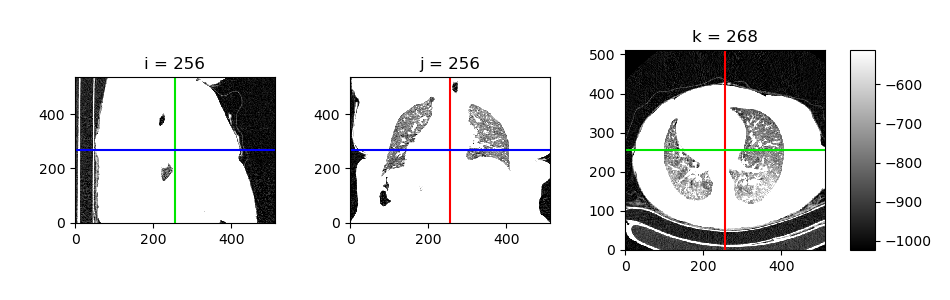

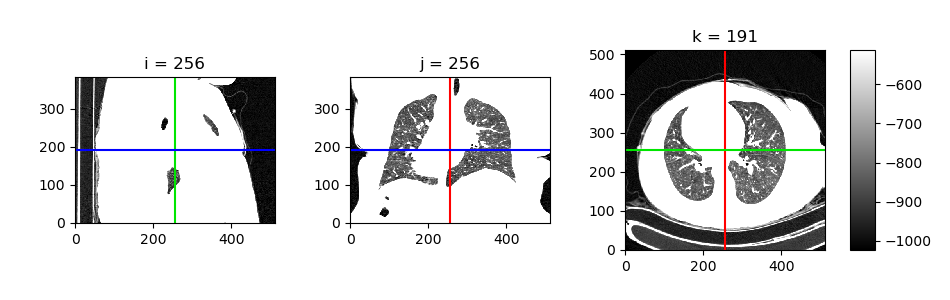

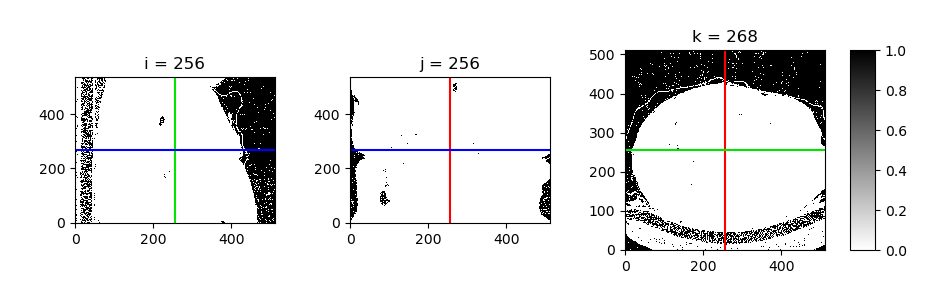

In [10]:
mpl_viz.SliceViewer(img0.get_fdata(), vox_spacing=spacing0, **img_kws)
mpl_viz.SliceViewer(img1.get_fdata(), vox_spacing=spacing1, **img_kws)

emph = (img0.get_fdata() <= -950)
mpl_viz.SliceViewer(emph, vox_spacing=spacing0, cmap='binary', vmin=0, vmax=1)

# Preprocessing tests

In [11]:
proc_config = {
    'image_resampling': {
        'spacing': (1.0, 1.0, 1.0),
        'interpolation': 'linear',
        'default_value': -1024.
    },
    'image_segmentation': {
        'tasks': [
            {
                'task_name': 'total',
                'roi_subset': [
                    'lung_upper_lobe_right',
                    'lung_middle_lobe_right',
                    'lung_lower_lobe_right',
                    'lung_upper_lobe_left',
                    'lung_lower_lobe_left',
                ],
            },
        ],
        'combine': True
    },
    'image_registration': {
        'method': 'unigradicon',
        'args': {
            'model': 'gradiconlung',
            'io_sim': 'lncc2',
            'io_iterations': 50,
            'io_sigma': 1,
            'loss_function_masking': True,
            'intensity_conservation': True
        }
    },
    'region_labeling': {
        'roi_order': [
            'lung_upper_lobe_right',
            'lung_middle_lobe_right',
            'lung_lower_lobe_right',
            'lung_upper_lobe_left',
            'lung_lower_lobe_left',
        ],
        'region_filter': {
            'min_voxels': 30,
            'keep_largest': True
        }
    },
    'mesh_generation': {
        'use_affine_spacing': True,
        'mesh_parameters': {
            'max_facet_distance': 0.75,
            'max_cell_circumradius': 5.0,
            'lloyd': True,
            'odt': True
        }
    },
    'mesh_interpolation': {}
}

In [12]:
examples = ds.list_examples(
    subjects='../../data/COPDGene/sample1000_2025-05-21.csv',
    state_pairs=[('EXP', 'INSP')],
    variant='TEST',
    pipeline_tags={
        'image_segmentation': 'tseg',
        'image_registration': 'lung'
    }
)

In [13]:
%autoreload
import project.preprocessing.api as api

bin_path = '/ocean/projects/asc170022p/mtragoza/mambaforge/envs/warp/bin'
os.environ['PATH'] = bin_path + ':' + os.environ['PATH']

for ex in examples[:1]:
    api.preprocess_example(ex, proc_config)

print('Done')

INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_combined.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz exists; Skipping stage create_multi_region_map
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_tseg_combined.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_tseg_regio

In [14]:
import numpy as np

img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
mask = project.core.fileio.load_nibabel(ex.paths['region_map']).get_fdata()

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
print(spacing0)

spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))
print(spacing1)

img0.affine

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz
(-1.0, 1.0, 1.0)
(-1.0, 1.0, 1.0)


array([[  -1.       ,   -0.       ,    0.       ,  167.5      ],
       [  -0.       ,    1.       ,   -0.       ,   -6.5      ],
       [   0.       ,    0.       ,    1.       , -318.3001709],
       [   0.       ,    0.       ,    0.       ,    1.       ]])

In [15]:
img_kws = dict(cmap='gray', vmin=-1024, vmax=-256)

cmap = mpl_viz.get_label_cmap(n_labels=10, select=None, include_bg=True)
mask_kws = dict(cmap=cmap, vmin=0, vmax=10)

disp_kws = dict(cmap='seismic', vmin=-20, vmax=20)

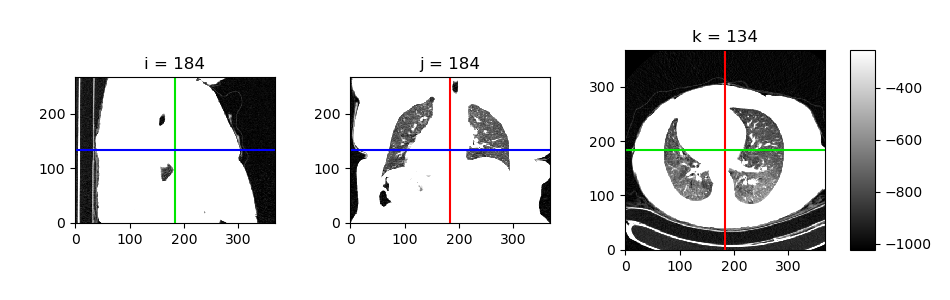

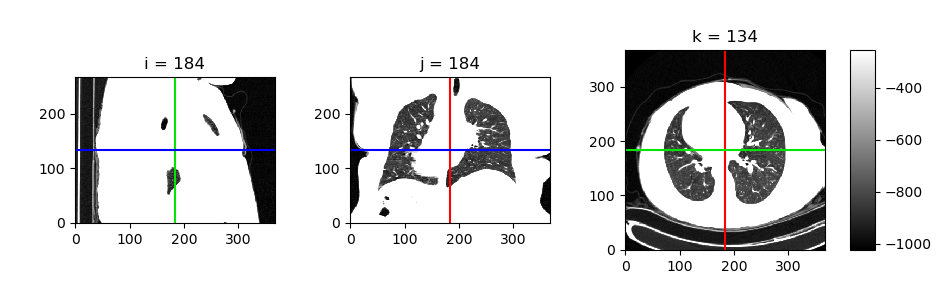

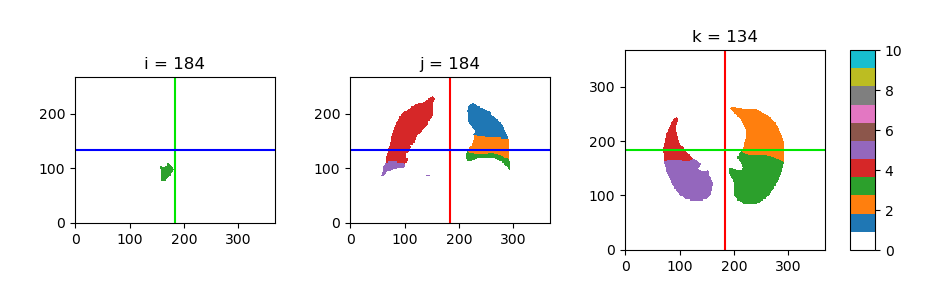

In [16]:
mpl_viz.SliceViewer(img0.get_fdata(), vox_spacing=spacing0, **img_kws)
mpl_viz.SliceViewer(img1.get_fdata(), vox_spacing=spacing1, **img_kws)
mpl_viz.SliceViewer(mask, vox_spacing=spacing0, **mask_kws)

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_tseg_lung_INSP.nii.gz


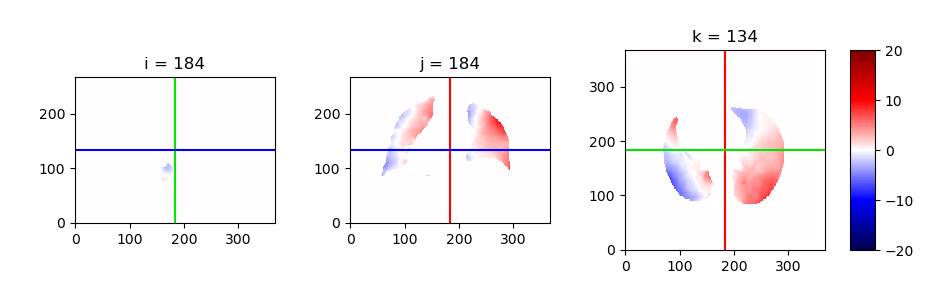

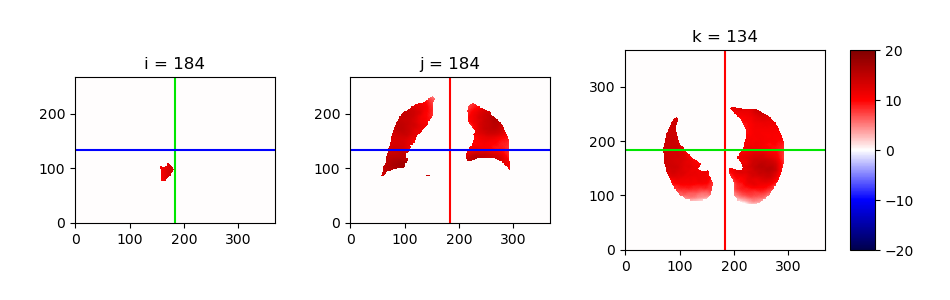

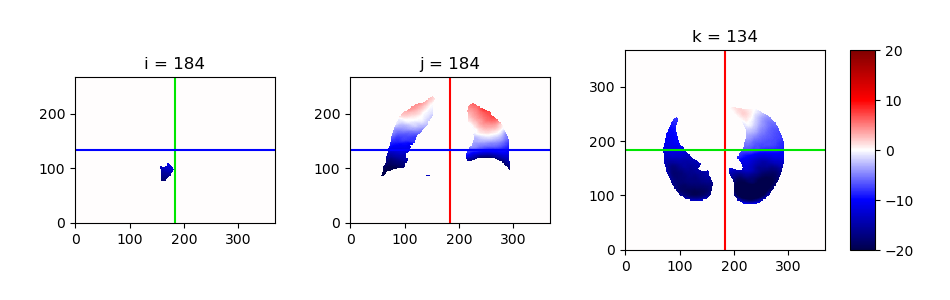

In [17]:
disp_path = str(ex.paths['disp_field'])
disp = project.core.fileio.load_nibabel(disp_path).get_fdata()

mpl_viz.SliceViewer(disp[...,0] * (mask > 0), vox_spacing=spacing0, **disp_kws)
mpl_viz.SliceViewer(disp[...,1] * (mask > 0), vox_spacing=spacing0, **disp_kws)
mpl_viz.SliceViewer(disp[...,2] * (mask > 0), vox_spacing=spacing0, **disp_kws)

In [18]:
mesh = project.core.fileio.load_meshio(ex.paths['interp_mesh'])
mesh

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tseg_regions_pyg_lung_INSP_int.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true
  Cell data: medit:ref, region, image, u_true

In [19]:
import project.visual.pyvista as pv_viz

In [32]:
np.arange(0, 1000, 4).shape

(250,)

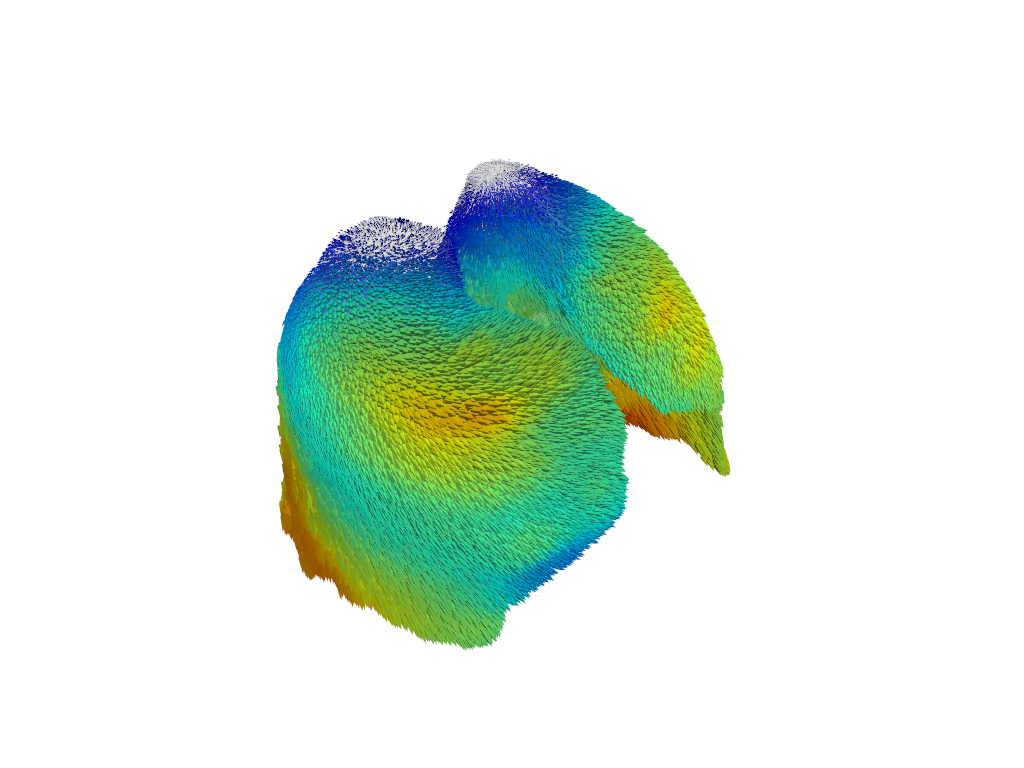

In [39]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter()
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet')
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')